# Eksplorativna analiza podataka 

**Aleksandar Sredojević**

U ovoj radnoj svesci ću da istražim podatke o proizvodima
da ih pripremim za treniranje i poređenje modela,
kao i za bazu samih skripti za treniranje i korišćenje modela u produkciji.

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Prvi pogled na podatke

In [13]:
df = pd.read_csv("data/products.csv")

print(f"Broj proizvoda: {df.shape[0]}")
print(f"Broj kolona: {df.shape[1]}")
print("Tipovi podataka:")
print(df.dtypes)
df.sample(30)

Broj proizvoda: 35311
Broj kolona: 8
Tipovi podataka:
product ID           int64
Product Title       object
Merchant ID          int64
 Category Label     object
_Product Code       object
Number_of_Views    float64
Merchant Rating    float64
 Listing Date       object
dtype: object


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
29447,40930,gorenje rk6192ebk fridge feeezer combi less fr...,131,Fridge Freezers,TG-6487-UD,1777.0,4.8,6/27/2023
13088,22647,nikon a100 20mp 5x zoom compact camera,181,Digital Cameras,OB-8318-UE,1711.0,3.8,12/1/2024
10296,16683,NaN,66,CPUs,LW-9172-OG,837.0,4.5,6/10/2024
25046,35933,lec cf100lwmk2 chest freezer,294,Freezers,DO-6656-OJ,761.0,1.2,8/15/2022
15319,25014,swan standard microwave sm22030on orange,22,Microwaves,HM-9600-JZ,3624.0,3.3,3/6/2022
27721,38933,smeg fridges and freezers fab50rcr 220 240 v,314,Fridge Freezers,UR-6779-ZH,1214.0,3.5,12/29/2023
11081,17471,intel xeon x5560 processor 2.8 ghz 8 mb smart ...,14,CPUs,ZM-2078-LW,1477.0,2.3,8/31/2024
26321,37323,bosch kgn39vw35g fridge freezer no frost 279 8...,131,Fridge Freezers,PI-8870-PP,260.0,2.8,8/5/2023
8204,14330,amd a series a6 9500e apu 3ghz 1mb l2 box proc...,14,CPUs,ZL-1091-FK,270.0,3.7,12/15/2024
32654,44476,liebherr tp 1764 under counter fridge premium,293,Fridges,FS-6415-RV,1470.0,1.1,10/16/2024


U ovom skupu podataka ima dovoljno za trening i test skup,
međutim mali broj kolona nam zaista pomaže za treniranje modela:

* Kolone poput `Product ID`, `Merchant ID` i `Product Code` su izabrane slučajno
  i samo će da zbune model.
* Kolone poput `Merchant Rating`, `Listing Date` i `Number_of_Views` verovatno ne zavise od kategorije proizvoda,
  sigurno mnogo manje od naslova.

Izbacićemo sve nepotrebno iz DataFrame i kad smo tu skratićemo imena kolona za lakši zapis dalje.

In [20]:
# Originalni skup podataka je imao ekstra razmak u imenu kolone Category Label
df = df.filter(["Product Title", " Category Label"])
df = df.rename(columns={
    "Product Title": "title",
    " Category Label": "category"
})

## Prazne vrednosti i tipovi

Naše dve kolone trebaju biti str i category,
ali su obe object.
    To je verovatno zbog nedostajućih vrednosti.

In [27]:
print(df.isnull().sum())
print((df.isnull().sum() / len(df)) * 100)
print(df[df.category.isnull()])

title       172
category     44
dtype: int64
title       0.487100
category    0.124607
dtype: float64
                                                   title category
162    apple iphone 7 4.7 single sim 4g 2gb 128gb 196...      NaN
762    cat s60 11.9 cm 4.7 1280 x 720 pixels flat 16 ...      NaN
1670                       microsoft lumia 650 lte black      NaN
2652                               motorola moto x style      NaN
2814                            doro phoneeasy 615 black      NaN
3429                                      sony xperia c4      NaN
7741   boxed processor amd ryzen 3 1200 4 x 3.1 ghz quad      NaN
9113   intel core i5 4570te 2.7 ghz 2 cores 4 threads...      NaN
9134   intel core i3 i3 3250 dual core 2 core 3.50 gh...      NaN
9780                       amd opteron 6262 he processor      NaN
9968   hewlett packard enterprise 588062 b21 2.93ghz ...      NaN
10635  hewlett packard enterprise amd opteron 6278 ki...      NaN
11075  amd am3 phenom ii 555 95w am3 dua

U skupu postoji veoma mali broj nedostajućih vrednosti,
manje od 1%.

Za nedostajuće naslov se nemože išta uraditi,
međutim neko ko zna da kategoriše proizvode bi lako mogao da dopuni 44 nekategorisanih proizvoda.

Radi jednostavnosti ja ću da izbacim sve nedostajuće vrednosti.
Na kraju ću da pretvorim kolone u potrebne tipove.

In [34]:
df_dropped = df.dropna()
print(f"Izbačeno je {len(df)-len(df_dropped)} redova ({(len(df)-len(df_dropped))/len(df) * 100}%)")
df = df_dropped
df.title = df.title.astype('str')
df.category = df.category.astype('category')

Izbačeno je 0 redova (0.0%)


## Raspodela podataka

In [40]:
((df.category.value_counts())/len(df) * 100).sort_values(ascending=False)

category
Fridge Freezers     31.997948
Mobile Phones       11.559722
Washing Machines    11.440050
CPUs                10.915774
TVs                 10.089469
Dishwashers          9.701960
Digital Cameras      7.661842
Microwaves           6.633235
Name: count, dtype: float64

Ovde vidimo problem sa našim kategorijama: nisu sve kategorije isto imenovane.
Npr. postoje kategorije "Fridge Freezers", Fridges, Freezers i fridge, kao i CPUs i CPU, Mobile Phones i Mobile Phone.

In [39]:
df.category = df.category.cat.rename_categories({
    "CPU": "CPUs",
    "Mobile Phone": "Mobile Phones",
    "fridge": "Fridge Freezers",
    "Fridges": "Fridge Freezers",
    "Freezers": "Fridge Freezers"
})

C:\Users\Sasa\AppData\Local\Temp\ipykernel_27460\78764236.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df.category = df.category.replace({


Sad ako se ponovo pokrene izveštaj o raspodeli kategorija,
može da se vidi da je raspodela nejednaka,
ali postoji dovoljno proizvoda u svakoj da se koristi u modelu.
Na raspodelu će se morati obraćati pažnja kada se bude delio skup podataka.

## Inženjering karakteristika

Za bolje predikcije ispitaćemo raspodele dodatnih karakteristika po kategorijama.

### Dužina naslova

Statistike o dužini teksta:
count    35096.000000
mean        52.984813
std         22.438958
min          5.000000
25%         39.000000
50%         52.000000
75%         65.000000
max        200.000000
Name: length, dtype: float64
Statistike o dužini teksta po kategorijama:
                   length                                                     
                    count       mean        std   min   25%   50%   75%    max
category                                                                      
CPUs               3831.0  67.021404  20.210202  11.0  55.0  65.0  76.0  190.0
Digital Cameras    2689.0  50.115284  24.548060   6.0  34.0  44.0  61.0  180.0
Dishwashers        3405.0  50.206755  17.989980  10.0  39.0  51.0  61.0  192.0
Fridge Freezers   11230.0  51.837756  19.669218   8.0  39.0  50.0  65.0  173.0
Microwaves         2328.0  51.811856  18.798911  11.0  39.0  52.0  65.0  164.0
Mobile Phones      4057.0  46.240818  30.759028   5.0  27.0  40.0  57.0  200.0
TVs         

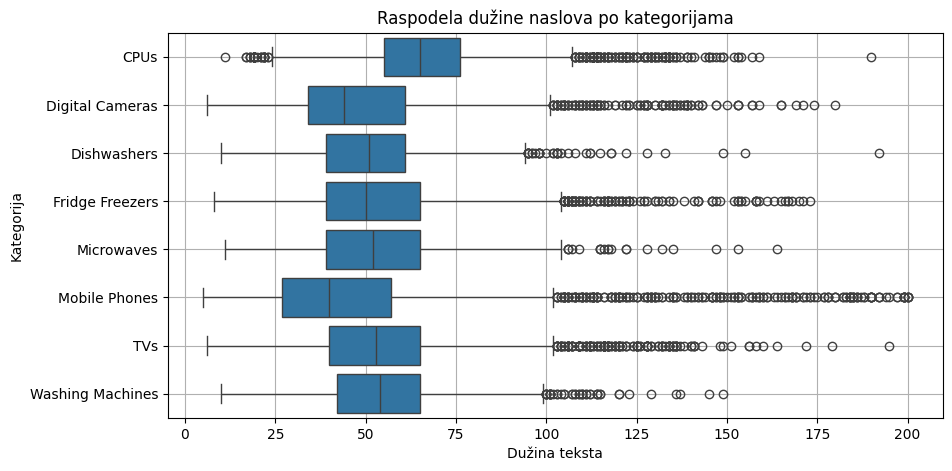

In [43]:
df["length"] = df.title.str.len()
print("Statistike o dužini teksta:")
print(df.length.describe())
print("Statistike o dužini teksta po kategorijama:")
print(df.groupby("category", observed=False).describe())
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="length", y="category")
plt.title("Raspodela dužine naslova po kategorijama")
plt.xlabel("Dužina teksta")
plt.ylabel("Kategorija")
plt.grid(True)
plt.show()

Većinu kategorija ima istu raspodelu dužine imena, ali CPUs je uglavnom veće. Vredi koristiti ovu karakteristiku.

### Broj brojeva

Koliko cifara ima u imenu proizvoda? Neki proizvodi imaju više brojeva u njihovim imenima.

Statistike o broju cifara:
count    35096.000000
mean         6.698997
std          4.414066
min          0.000000
25%          4.000000
50%          6.000000
75%          9.000000
max         54.000000
Name: number_of_digits, dtype: float64
Statistike o broju cifara po kategorijama:
                    count       mean       std  min  25%   50%   75%   max
category                                                                  
CPUs               3831.0  12.117724  4.875738  0.0  9.0  11.0  14.0  36.0
Digital Cameras    2689.0   5.807735  4.221349  0.0  3.0   5.0   8.0  29.0
Dishwashers        3405.0   5.313950  2.634144  0.0  4.0   5.0   7.0  30.0
Fridge Freezers   11230.0   5.276670  3.108416  0.0  4.0   5.0   7.0  41.0
Microwaves         2328.0   5.698454  3.081078  0.0  4.0   5.0   8.0  29.0
Mobile Phones      4057.0   4.957604  4.633158  0.0  2.0   4.0   6.0  42.0
TVs                3541.0   9.281276  4.370738  0.0  7.0   9.0  11.0  54.0
Washing Machines   4015.0   7.340722  3.

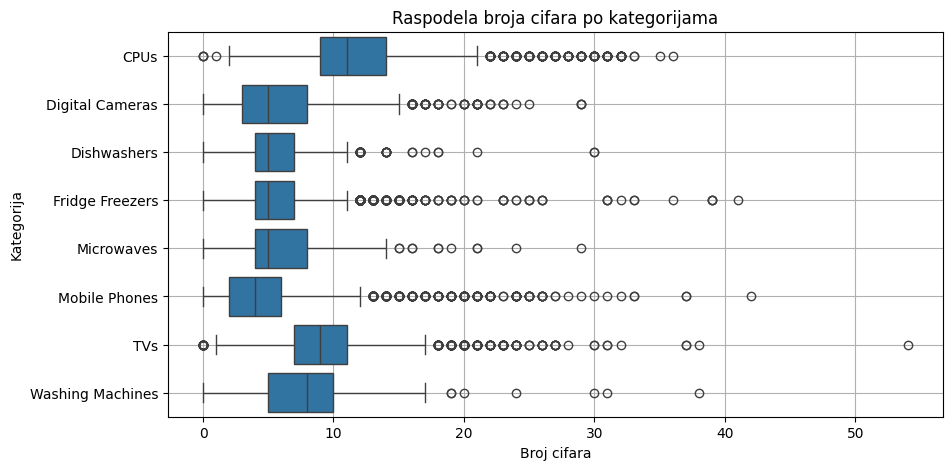

In [47]:
df["number_of_digits"] = df.title.str.replace(r"\D*(\d*)", r"\1", regex=True).str.len()
print("Statistike o broju cifara:")
print(df.number_of_digits.describe())
print("Statistike o broju cifara po kategorijama:")
print(df.groupby("category", observed=False).number_of_digits.describe())
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="number_of_digits", y="category")
plt.title("Raspodela broja cifara po kategorijama")
plt.xlabel("Broj cifara")
plt.ylabel("Kategorija")
plt.grid(True)
plt.show()

In [48]:
Ovde se opet ističu CPUs po broju cifara, dok ostale kategorije su mnogo bliže. Ovo isto deluje kao korisna karakteristika.

SyntaxError: invalid syntax (1342681160.py, line 1)

## Treniranje modela

In [49]:
from sklearn.model_selection import train_test_split

X = df[["title", "length", "number_of_digits"]]
y = df.category
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Preprocesiranje

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer(transformers=[
    ("title", TfidfVectorizer(), "title"),
    ("length", MinMaxScaler(), "length"),
    ("number_of_digits", MinMaxScaler(), "number_of_digits")
])